In [1]:
import pandas as pd
import seaborn as sns
from scipy.stats import zscore
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys,os
sys.path.append( '../spatial_analysis/')
from utils import generate_anndata_from_ark_analysis
output_fig = '../figures/diff_expr_marker/'

In [3]:
cell_som_cluster = pd.read_csv('../../pixie/all_cell_output_dir/cell_som_cluster_channel_avg.csv')

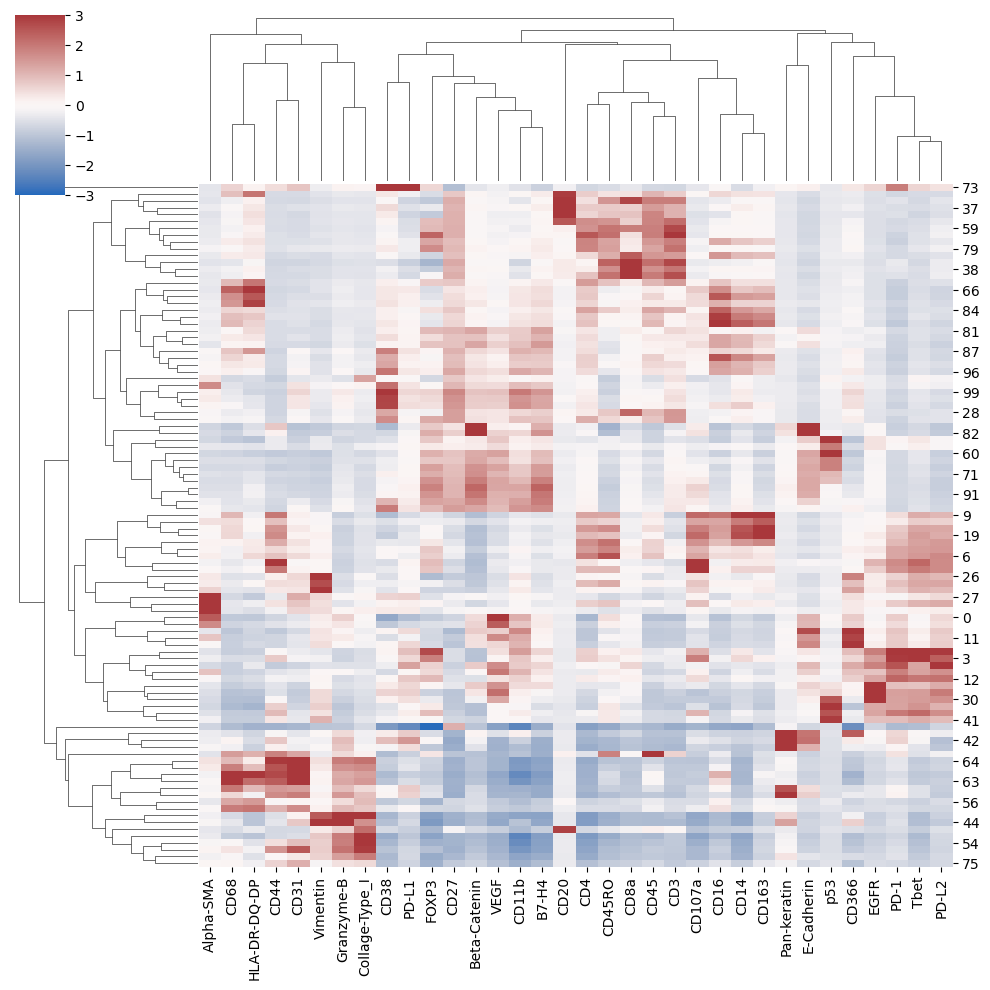

In [4]:
num_clusters = cell_som_cluster.iloc[:,1:cell_som_cluster.columns.get_loc('cell_meta_cluster')]
sns.clustermap(num_clusters,cmap ='vlag',z_score=1,vmin = -3,vmax = 3)
plt.show()

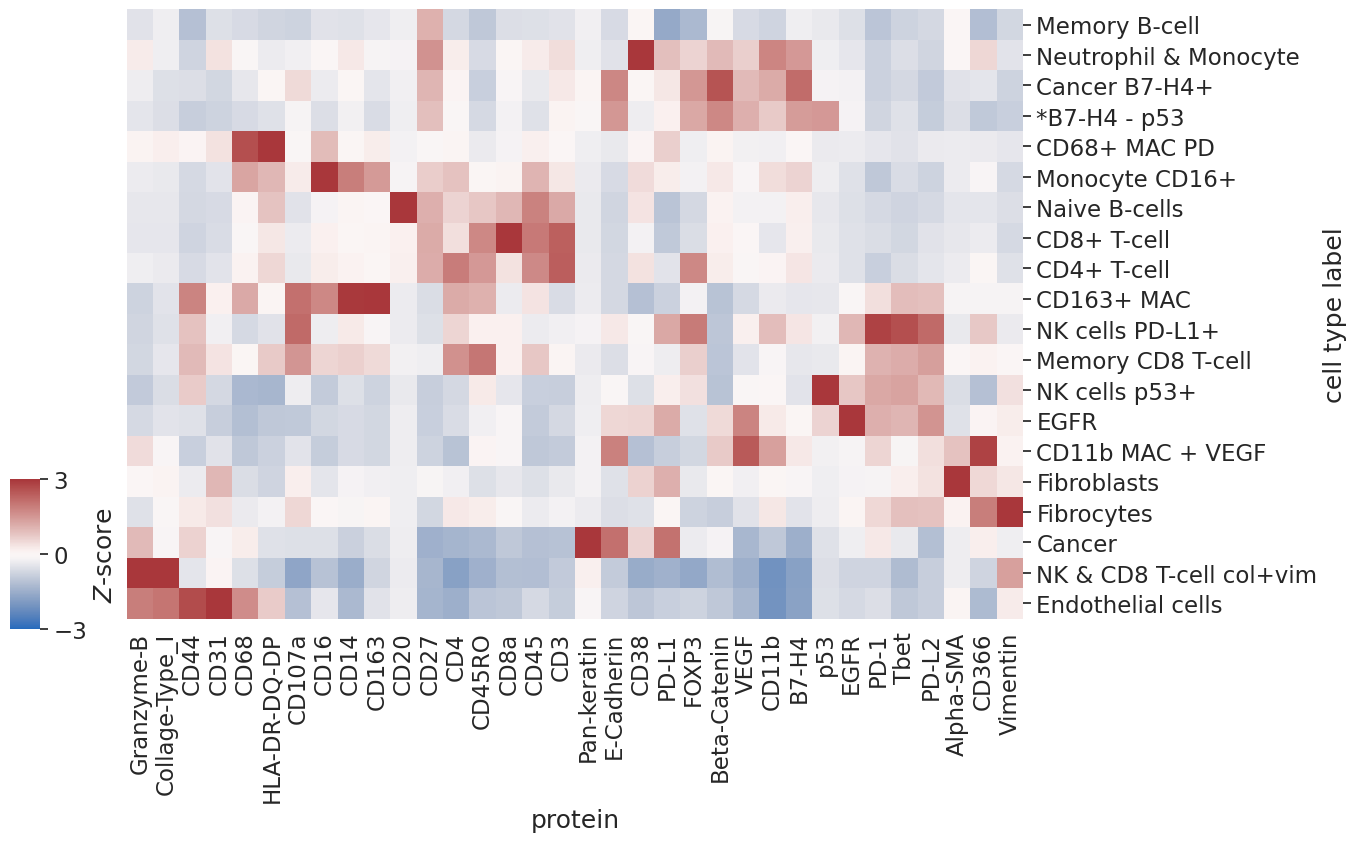

In [20]:
cell_meta = pd.read_csv('../../pixie/all_cell_output_dir/cell_meta_cluster_channel_avg.csv')
num_meta =  cell_meta.iloc[:,1:cell_meta.columns.get_loc('cell_meta_cluster_rename')+1]#.sort_values(by = 'cell_meta_cluster_rename')
num_meta = num_meta.set_index('cell_meta_cluster_rename')
cg = sns.clustermap(num_meta,cmap ='vlag',z_score=1,vmin = -3.,vmax = 3.,cbar_pos=(0.09,0.2,.02,0.15),cbar_kws={"ticks":[-3,0,3]},figsize = (15,10))
cg.ax_heatmap.set(xlabel = 'protein',ylabel = 'cell type label')
cg.ax_cbar.set(ylabel = '$Z$-score')
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
sns.set(font_scale=1.5)
#plt.tight_layout()
#plt.savefig(output_fig+'meta_cluster.png')

/tmp/ipykernel_526883/987825216.py:10: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
/tmp/ipykernel_526883/987825216.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


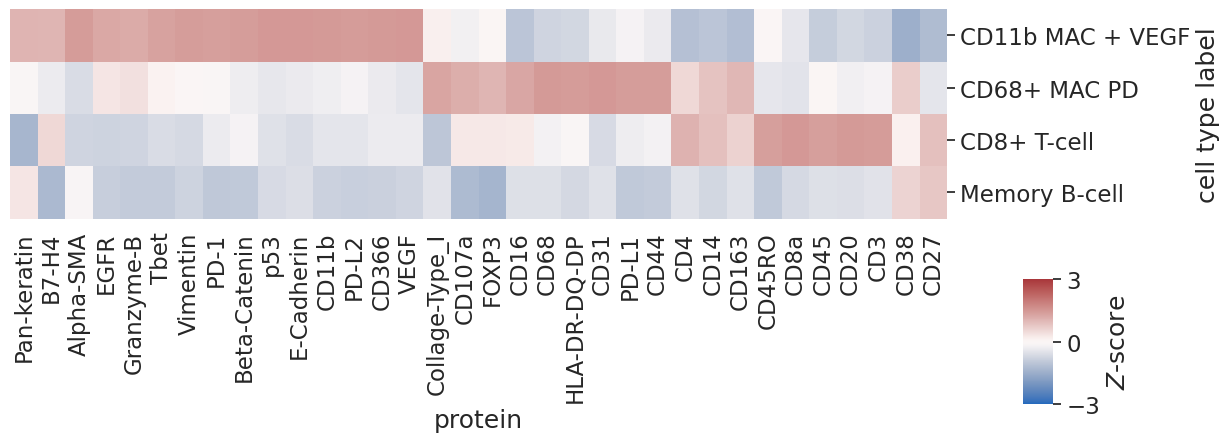

In [39]:
cell_meta = pd.read_csv('../../pixie/all_cell_output_dir/cell_meta_cluster_channel_avg.csv')
num_meta =  cell_meta.iloc[:,1:cell_meta.columns.get_loc('cell_meta_cluster_rename')+1]#.sort_values(by = 'cell_meta_cluster_rename')
num_meta = num_meta.set_index('cell_meta_cluster_rename')
cg = sns.clustermap(num_meta.loc[['CD11b MAC + VEGF','CD68+ MAC PD','CD8+ T-cell','Memory B-cell']],cmap ='vlag',z_score=1,vmin = -3.,vmax = 3.,cbar_pos=(0.85,0.05,.02,0.25),cbar_kws={"ticks":[-3,0,3]},figsize = (15,5))
cg.ax_heatmap.set(xlabel = 'protein',ylabel = 'cell type label')
cg.ax_cbar.set(ylabel = '$Z$-score')
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
sns.set(font_scale=1.5)
plt.tight_layout()
#plt.savefig(output_fig+'meta_cluster_red.png')


In [28]:
sns.clustermap?

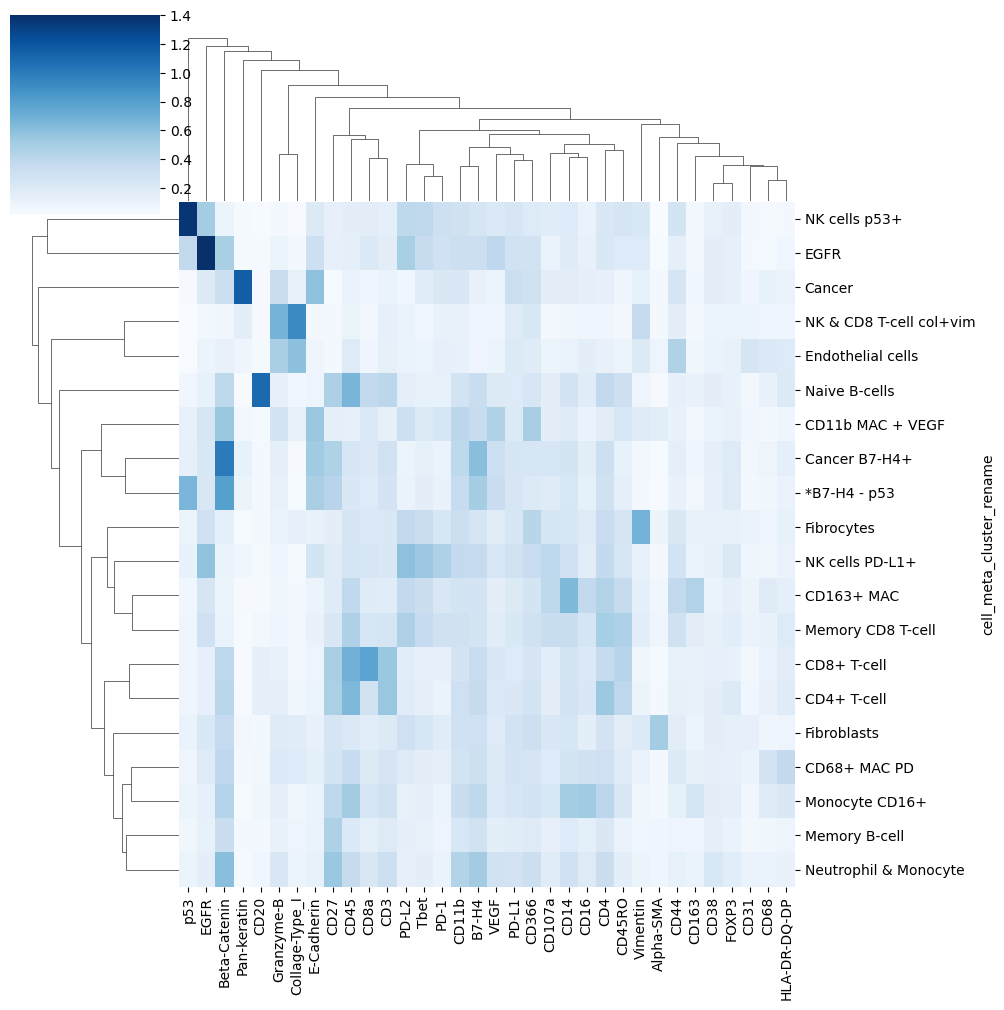

In [64]:
sns.clustermap(num_meta,cmap ='Blues',cbar_pos=(0,0.8,.15,0.2))

In [66]:
output_fig

'../figures/diff_expr_marker/'

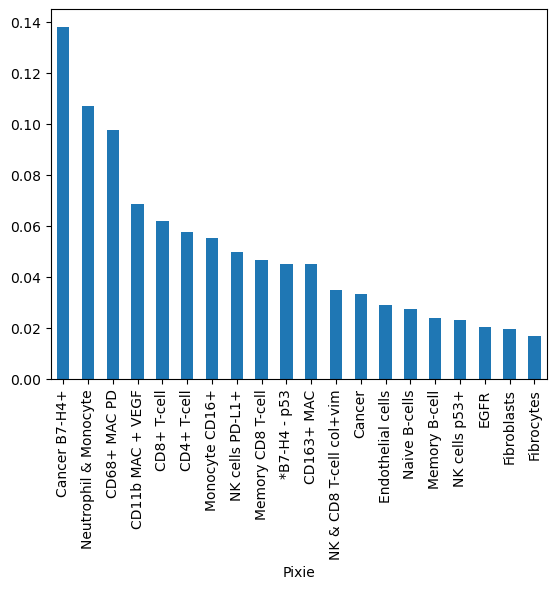

In [67]:
adata.obs.Pixie.value_counts(normalize = True).plot(kind = 'bar')
#plt.xticks(rotation = 45)
#plt.savefig(output_fig+'cell_type_proportion')

In [46]:
import scanpy as sc
adata = generate_anndata_from_ark_analysis()
adata.X = adata.X/np.quantile(adata.X,0.95,axis = 0).shape
adata.X[adata.X>1] = 1

/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [47]:
# get fovs having more than 1000 cells
fovs = adata.obs.acquisition_ID.value_counts()[adata.obs.acquisition_ID.value_counts()>=1000].index
adata = adata[adata.obs.acquisition_ID.isin(fovs)]#remove fovs with less than 1000 cells

/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to m

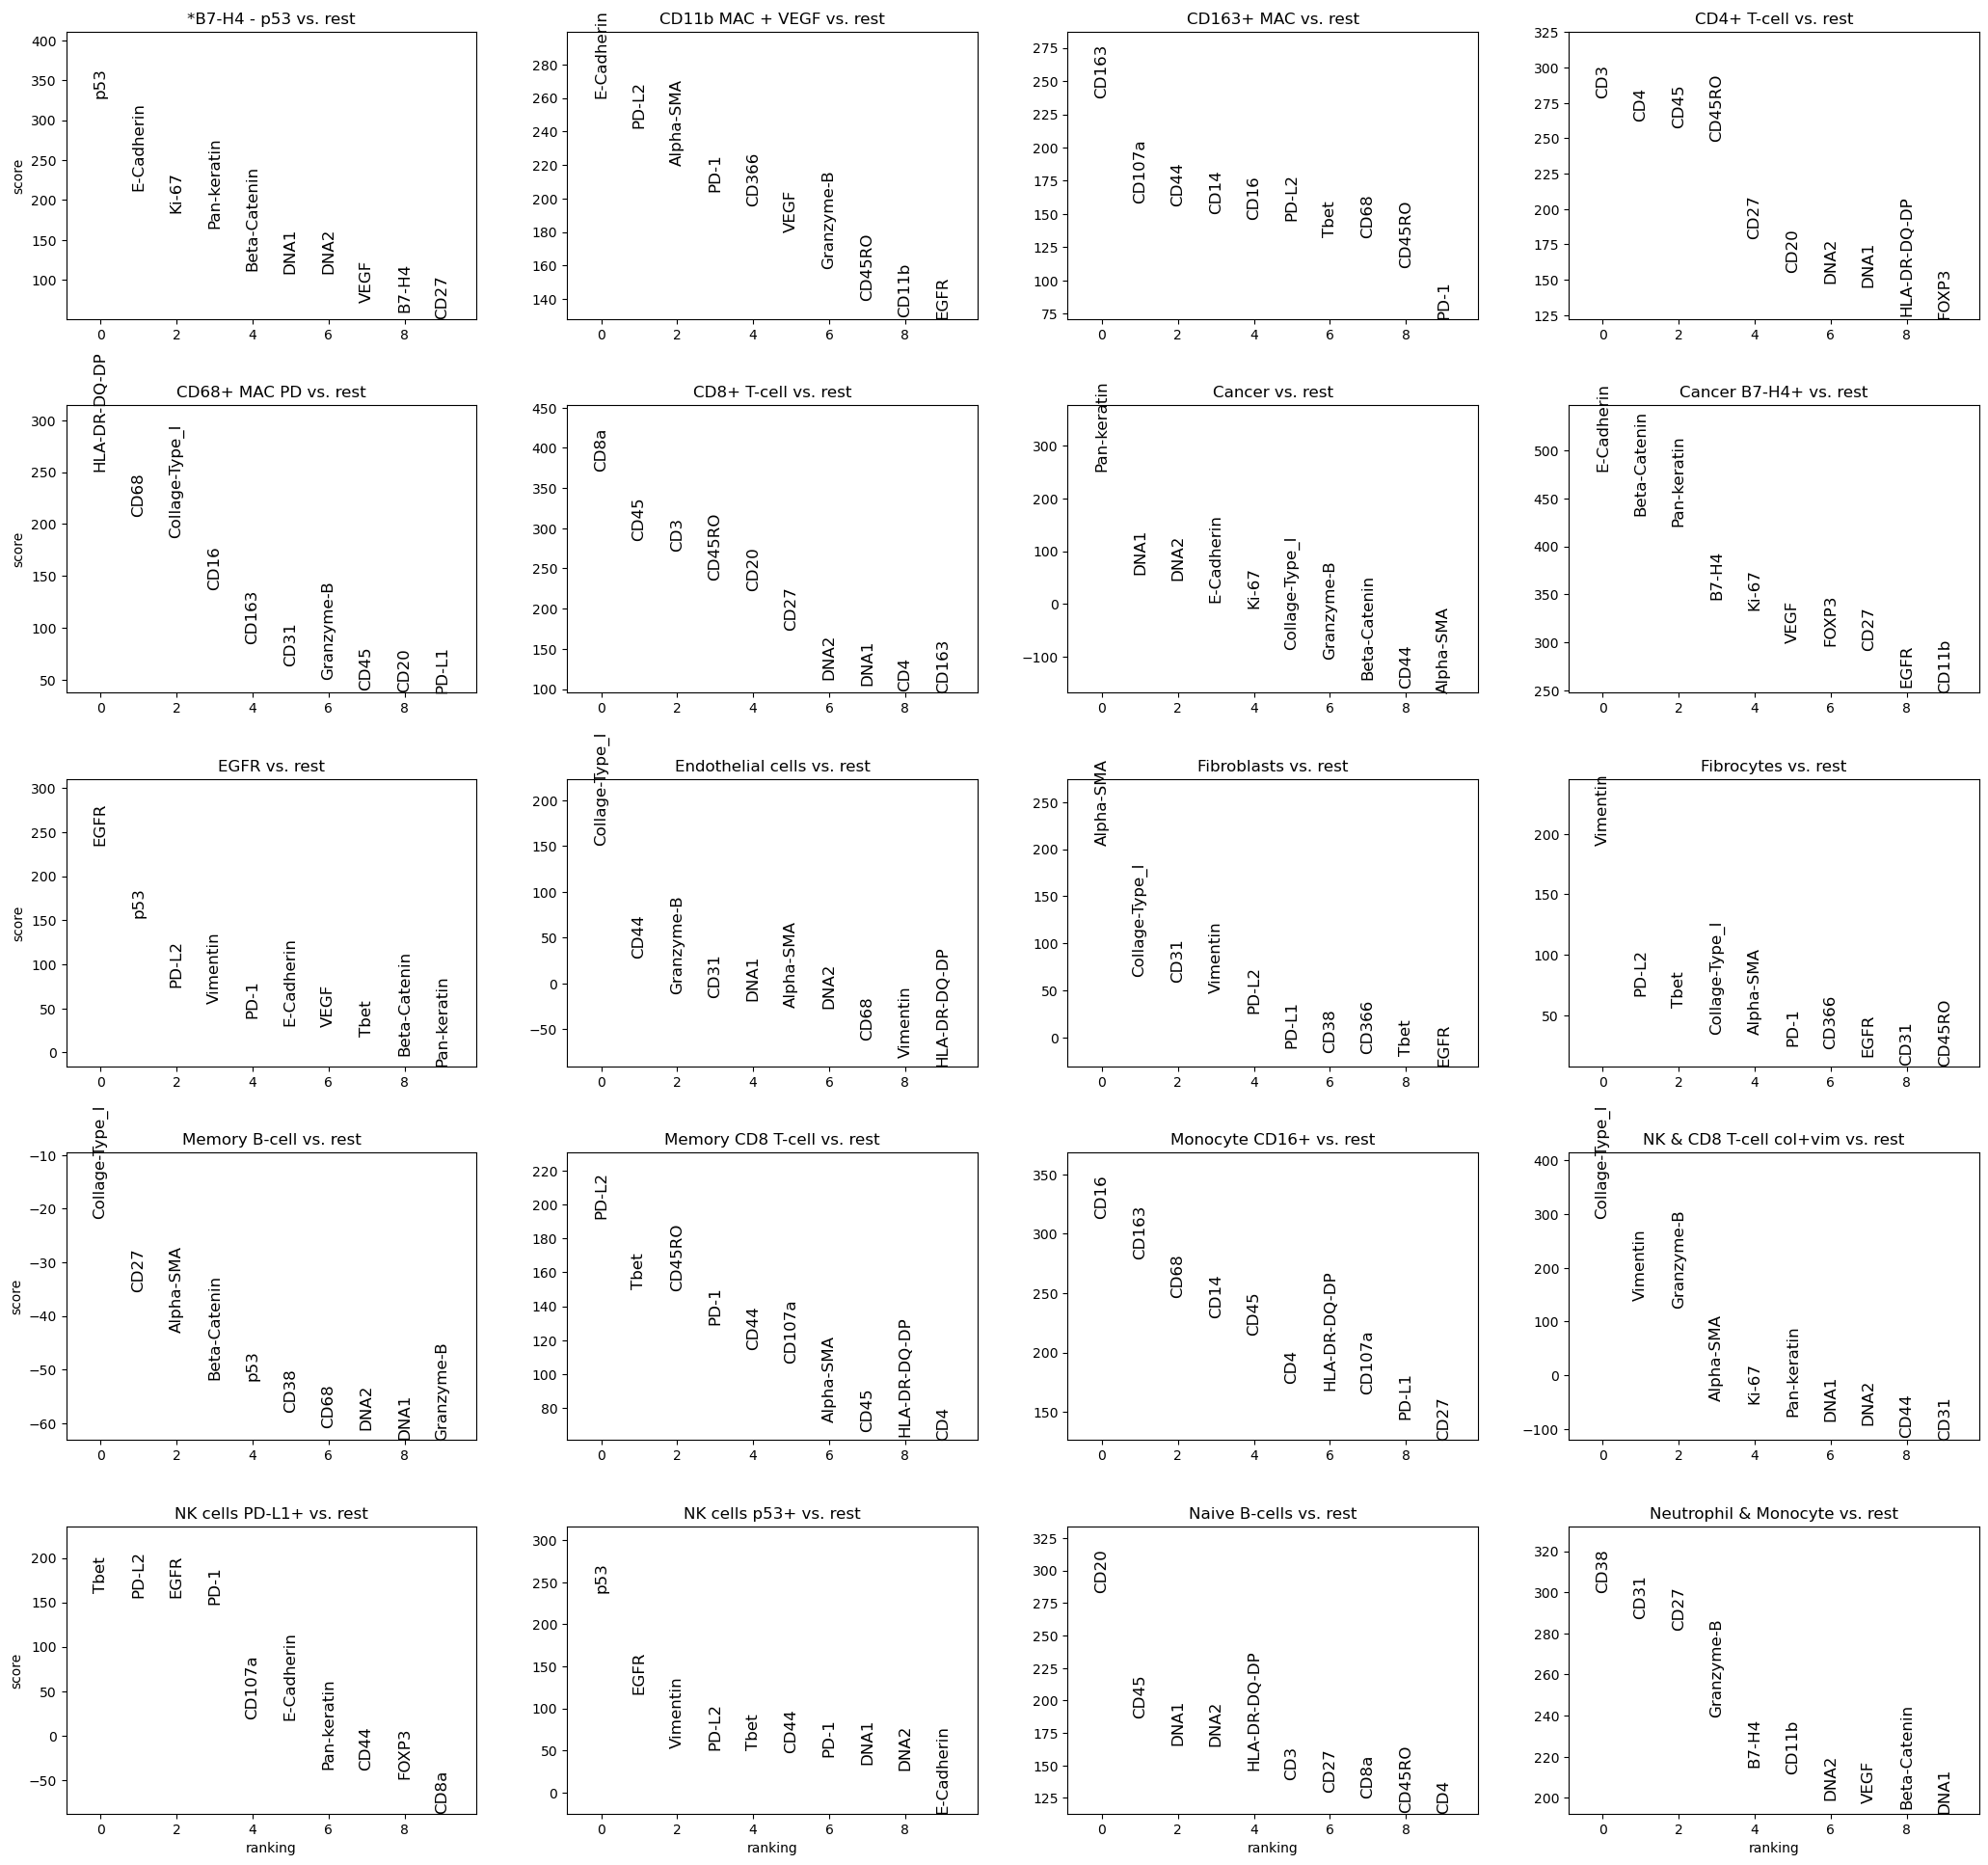

In [48]:
sc.tl.rank_genes_groups(adata, 'Pixie', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False,show=False,fontsize=12)
#plt.savefig(output_fig+'/diff_expr_marker/cell_type_signature.png')

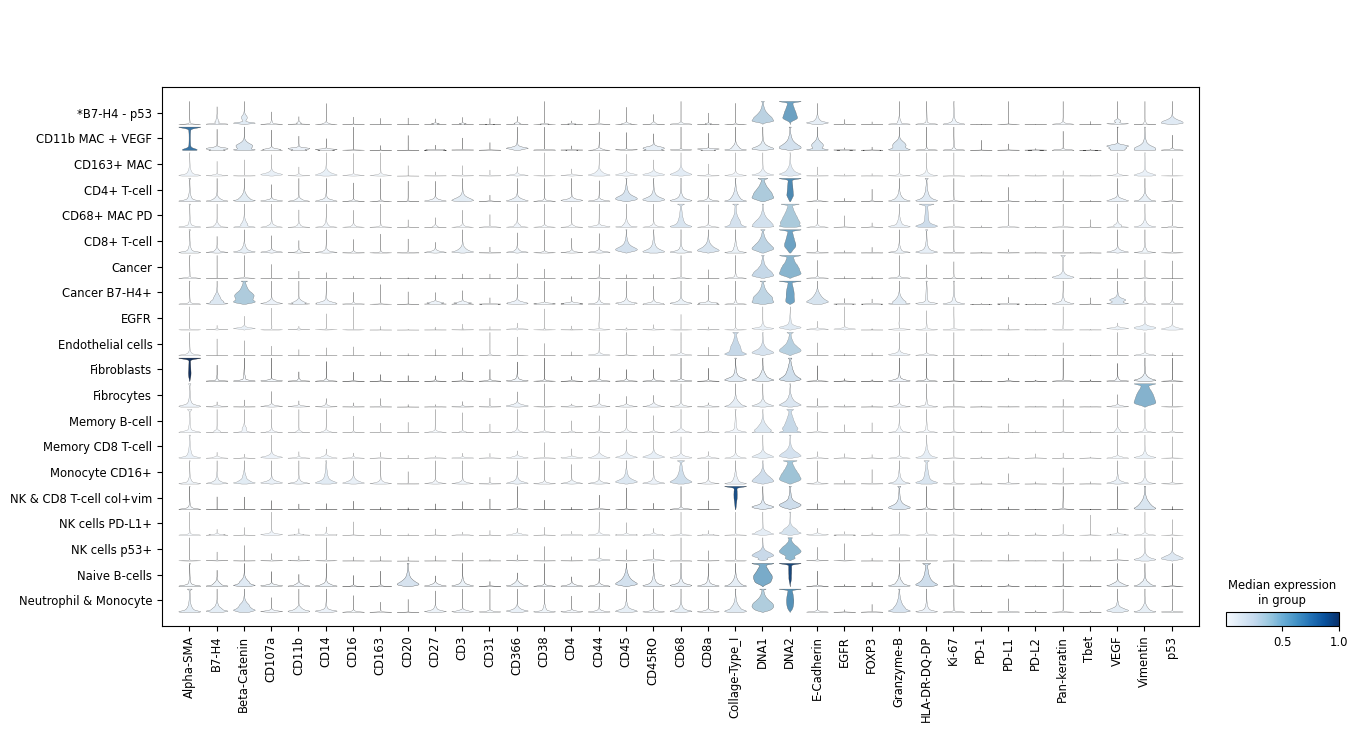

In [49]:
sc.pl.stacked_violin(adata,var_names = adata.var.index, groupby='Pixie',show = False);
#plt.savefig(output_fig+'/diff_expr_marker/cell_type__stacked_violing')

In [45]:

#plt.hist(adata.X.reshape(-1),20)

array([[0.02400859, 0.04439095, 0.01049406, ..., 0.07414779, 0.05084864,
        0.004914  ],
       [0.01186394, 0.0066368 , 0.00504318, ..., 0.02507198, 0.176109  ,
        0.01077913],
       [0.37299113, 0.0110851 , 0.        , ..., 0.03442449, 0.89249186,
        0.00948039],
       ...,
       [0.07973502, 0.02899032, 0.04455549, ..., 0.02253982, 0.00415655,
        0.02710249],
       [0.33423898, 0.05482289, 0.13214968, ..., 0.10554463, 0.05904529,
        0.03463117],
       [0.36802553, 0.04997452, 0.22203726, ..., 0.0800318 , 0.04819702,
        0.04604309]])

In [99]:
a = adata.obs[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']].value_counts()
b = {}
a = pd.DataFrame(a).reset_index()
b = a['SAMPLE_TYPE_(CORE/RESECTION)'].value_counts()
c = a[a['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].Response.value_counts()
c

Response
pCR              80
Non-Responder    53
Name: count, dtype: int64

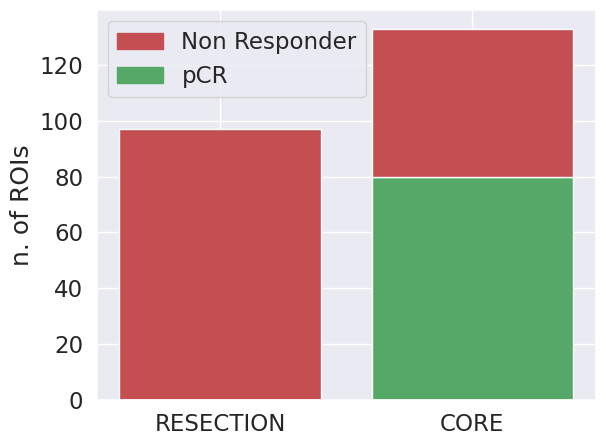

In [123]:
import matplotlib.patches as mpatches
sns.set(font_scale=1.5)
plt.bar(['RESECTION','CORE'],[b['RESECTION'],c['pCR']],color = ['C3','C2'])
plt.bar(['RESECTION','CORE'],[0,c['Non-Responder']],color = ['C0','C3'],bottom = [0,c['pCR']])
red_patch = mpatches.Patch(color='C3', label='Non Responder')
green_patch = mpatches.Patch(color='C2', label='pCR')
plt.legend(handles=[red_patch,green_patch])
plt.ylabel('n. of ROIs')
plt.tight_layout()
#plt.savefig('samples_ROI')


In [98]:
['RESECTION','CORE'],[b['RESECTION'],c['pCR']]
b['RESECTION']

SAMPLE_TYPE_(CORE/RESECTION)
CORE         133
RESECTION     97
Name: count, dtype: int64